In [2]:
# main.py
import sys
import os
import re
import string
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

#import geopandas

# Add the parent directory of your module to sys.path
module_path = "/Users/joel/PyProjects/police-journal"
sys.path.insert(0, module_path)

from pdf_processor import GranbyPDFProcessor

In [3]:
pd.__version__

'2.3.1'

In [4]:
plt.rcParams['font.family'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans' ]
pd.set_option('display.max_rows', 25)

date_format = mdates.DateFormatter('%b %Y')

In [5]:
geopath = "/Users/Shared/Granby_Police_Journals/geocoding"
geofile = os.path.join(geopath, "addresses_with_zips_geocodio_c82e6800d9ad78f18ce0c13b17071865a810bf95.csv")

# Initialize processor
processor = GranbyPDFProcessor(pdf_directory="/Users/Shared/Granby_Police_Journals", verbose=False)

In [6]:
# Process all PDFs and create DataFrame
df = processor.process_all_pdfs()

2025-12-24 17:37:38,888 - INFO - Found 160 PDF files to process
2025-12-24 17:37:40,595 - INFO - Created DataFrame with 6875 total records


In [7]:
# date ranges
early = df['Dispatch Date'].min().strftime("%b. %d, %Y")
late = df['Dispatch Date'].max().strftime("%b. %d, %Y")

exclusions = "Not shown: school traffic control, mutual aid, civil matters, and debriefs/paperwork."

## Geocoding
### Address cleanup

In [8]:
# clean addresses

def address_only(txt):
    
    txt = txt.upper().strip()
    txt = " ".join(txt.split())
    txt = txt.replace(" ,", ",")
    txt = txt.replace("(CATI)", "")
    txt = txt.replace(", EAST, GRANBY", ", EAST GRANBY")
    txt = txt.replace("ROUTE 10 TIRE", "ROUTE TEN TIRE")
    txt = " ".join(txt.split())
    txt = txt.replace(",,", ",")
    txt = txt.replace(", ,", ",")
    txt = txt.replace(" ,", ",")
    txt = " ".join(txt.split())
    txt = txt.replace(", RD, ", " RD, ")
    txt = txt.replace(", DR, ", " DR, ")
    txt = txt.replace("SOUTHWICK, SOUTHWICK", ", SOUTHWICK")
    txt = txt.replace("FFLOYDVILLERD", "FLOYDVILLE RD")

    txt = txt.replace("FEEDING, HILLS", "FEEDING HILLS")
    txt = txt.replace("17R EAST GRANBY RD, 17R EAST GRANBY RD,", "17R EAST GRANBY RD,")
    txt = txt.replace("375R NORTH GRANBY RD, 375R NORTH GRANBY RD,", "375R NORTH GRANBY RD,")
    txt = txt.replace("125 LOST ACRES RD, 150 LOST ACRES RD,", "150 LOST ACRES RD,")
    txt = txt.replace("AT STATE, LINE", "AT STATE, LINE")
    txt = txt.replace("SOUTH CONGRAGATIONAL, CHURCH", "242 Salmon Brook St, Granby").upper()
    
    
    txt = txt.replace("WINDSOR, LOCKS", "WINDSOR LOCKS")
    if txt.endswith(("33 TURKEY HILLS ROAD", "SEYMOUR ROAD Apt #: 6F")):
        txt = txt + ", EAST GRANBY"

    if txt.endswith("CONNECTICUT VALLEY COMMONS, LLC"):
        txt = txt + ", 19 HARTFORD AVE, GRANBY"

    placename = ''
    address = ''
    ambulances = ('SIMS', '165MED', 'LAFD-T', 'I4-BLS', '47MED', 'LA6', 'SIMSAL', 'GA14', 'LA3', '6F', 'SUFF', 'CANT')

    amb = re.search(r"(?P<begin>.*)(?P<amb>, (SIMS|165MED|LAFD-T|I4-BLS|47MED|LA6|SIMSAL|GA14|LA3|6F|SUFF|CANT|MORELLI, LORRAINE|SAYLOR, LAUREN)$)", txt)
    try:
        txt = amb.group("begin").strip()
    except:
        pass
    
    # append granby if missing
    if txt.endswith((' RD', ' ROAD', ' DRIVE', ' AV', ' ST', ' PLACE', ' LANE', ' STREET')):
        txt = txt.strip() + ", GRANBY"
        
    # remove apartment numbers
    apt = re.search(r"(?P<begin>.*)(?P<apt>APT.*)(?P<granby>, (GRANBY|SIMSBURY|EAST GRANBY|BLOOMFIELD|WINDSOR LOCKS).*)", txt)
    if apt:
        txt = apt.group("begin").strip() + apt.group("granby")

    # separate placename as text preceding first digit
    txt = txt[::-1]
        
    substr = re.match(r"(?P<address>.+\d)?(?P<placename>.*)", txt)
    if substr:
        if substr.group('placename'):
            placename = substr.group('placename')[::-1].strip()
        if substr.group('address'):
            address = substr.group('address')[::-1].strip()
    else:
        address = txt[::-1]

    if address.strip() == "":
        address = placename
        placename = ""

    placename = placename.strip(",")
        
    address = address.replace(",,", ",")
    address = address.replace(", ,", ",")
    address = address.replace(" ,", ",")
    address = address.replace(" 'S","")
    address = address.replace("MURTHA'S WAY - DUPLEX, CONSTRUCTION, ", "")
    address = address.replace("219 LOOMIS ST, 218 LOOMIS ST,", "219 LOOMIS ST,")
    address = address.replace("280 APARTMENTS, ", "")
    address = address.replace("8 THRONEBROOK RD, 8 THRONEBROOK RD,","8 THRONEBROOK RD,")
    address = address.replace("66, 150","150")
    address = address.replace("HARTOLAND","HARTLAND")
    address = address.replace(" NEAR NEW CELL, TOWER SITE","")
    address = address.replace("STRAWBERRYFIELDS", "STRAWBERRY FIELDS")

    address = address.replace("AMERICAN LEGION HALL POST, #", "244 NORTH GRANBY RD, GRANBY")
    address = address.replace("SUFFIELD PD", "11 Mountain Road, Suffield").upper()
    address = address.replace("WESTFIELD PD, WESTFIELD MA", "15 WASHINGTON ST, WESTFIELD")
    address = address.replace("WESTFIELD POLICE", "15 WASHINGTON ST, WESTFIELD")
    address = address.replace("SIMSBURY PD", "933 Hopmeadow St, Simsbury").upper()
    address = address.replace("GRANVILLE PD, GRANVILLE MA", "707 Main Rd, Granville").upper()
    address = address.replace("TOLLAND PD MA", "204 W Granville Rd, Tolland").upper()
    address = address.replace("WINDSOR PD", "110 Addison Rd, Windsor").upper()
    if address == "GRANVILLE PD":
        address = "707 Main Rd, Granville".upper()
    if address == "WESTFIELD PD":
        address = "15 WASHINGTON ST, WESTFIELD".upper()
    
    address = address.replace("BERG FIELD", "93 Hartland Blvd, East Hartland").upper()
    address = address.replace("SALMON BROOK SOUTH OF, ROTARY", "577 SALMON BROOK ST, GRANBY")
    address = address.replace("SALMON BROOK ST AT STATE, LINE", "SALMON BROOK ST @ ZIMMER ST, GRANBY")
    address = address.replace("TRANSFER STATION", "103 Old Stagecoach Rd, Granby").upper()
    address = address.replace("GRANBY HIGH SCHOOL", "54 N Granby Rd, Granby, Granby").upper()
    address = address.replace("SALMON BROOK DISTRICT WATER, CO", "15R Hartford Ave, Granby").upper()
    address = address.replace("GRANBY POLICE DEPT", "15 N Granby Rd, Granby").upper()
    address = address.replace("4, BRADLEY AIRPORT", "23 Schoephoester Rd, Windsor Locks").upper()
    if address == "BRADLEY AIRPORT CONNECTOR":
        address = "BRADLEY AIRPORT CONNECTOR @ Poquonock Ave, Windsor Locks".upper()
    if address == "BRADLEY AIRPORT":
        address = "180 Schoephoester Rd, Windsor Locks".upper()
      
    if address == "91 NORTH @ BRAINARD EXIT":
        address = "91 NORTH @ BRAINARD EXIT, Windsor Locks".upper()

    if address.endswith(" MA"):
        address = address[:-3]
    
    if address.endswith(("33 TURKEY HILLS ROAD", "SEYMOUR ROAD APT #: 6F")):
        address = address + ", EAST GRANBY"

    amb = re.search(r"(?P<begin>.*)(?P<amb> (SIMS|165MED|LAFD-T|I4-BLS|47MED|LA6|SIMSAL|GA14|LA3|6F|SUFF|CANT|MORELLI, LORRAINE|SAYLOR, LAUREN)$)", address)
    try:
        address = amb.group("begin").strip()
    except:
        pass

    if address.count(",") > 1:
        address = address.replace(",", "", 1)
        address = " ".join(address.split())
        
    if address.count(",") < 1:
        if address in ["NORTH HOLLOW/ GRANVILLE", "PHELPS/QUARRY", "UPPER MEADOW"]:
            address = address + ", GRANBY"
    
    address = address.replace('/',' @ ')
    address = " ".join(address.split())
    
    return [placename, address]

In [9]:
def get_state(x):

    townlist = ['GRANBY', 'EAST GRANBY', 'SIMSBURY', 'HARTLAND', 'SUFFIELD', 'BARKHAMSTED', 'WINDSOR LOCKS', 'HARTFORD', 'WINDSOR', 'BLOOMFIELD', 'CANTON', 'NEWINGTON',
                'TORRINGTON', 'EAST HARTLAND', 'MANCHESTER', 'GREENWICH', 'WINSTED', 'TARIFFVILLE', 'AVON', 'BURLINGTON', 'NEW BRITIAN', 'BRISTOL', 'PLAINVILLE', 'VERNON']
    malist = ['SOUTHWICK', 'GRANVILLE', 'CHICOPEE', 'WESTFIELD', 'FEEDING HILLS', 'SPRINGFIELD', 'OTIS']
    
    if x in townlist:
        return 'CT'
    elif x in malist:
        return 'MA'
    else:
        return ''


In [10]:
def extract_street(x):
    
    if x.count(",") > 0:
        street = x.split(",")[0]
        street = street.strip()
        return street
    return x

def extract_streetname(x):
    
    if x.count(",") > 0:
        street = x.split(",")[0]
        street = re.sub(r'\d', '', street)
        street = street.strip()
        return street
    return x

In [11]:
address_only('SHIGLEY VILLAGE, 53 SOUTH MAIN ST Apt #: 11B, EAST granby')

['SHIGLEY VILLAGE', '53 SOUTH MAIN ST, EAST GRANBY']

### Make clean addresses

In [12]:
df['Place Name'] = df['Location'].apply(lambda x: address_only(x)[0])
df['Address'] = df['Location'].apply(lambda x: address_only(x)[1])
df['Town'] = df['Address'].apply(lambda x: x.split(",")[::-1][0].strip())
df['State'] = df['Town'].apply(lambda x: get_state(x))
df['State'] = df['State'].where(~df['State'].isna(), df['Location'].str[-2:])
df['State'] = df['State'].where(df['State'].isin(['CT', 'MA', 'NY']), "")

df['Street'] = df['Address'].apply(lambda x: extract_street(x))
df['Street Name'] = df['Address'].apply(lambda x: extract_streetname(x))

In [13]:
df.head(2)

,CFS #,Dispatch Type,Call Type,Dispatch Date,Dispatch Time,Location,Unit Id,Primary Officer,File Date,Dispatch Timestamp,Dispatch Hour,Call Category,Place Name,Address,Town,State,Street,Street Name
0,2500007968,17,BUSINESS CHECK,2025-07-14,00:12,"STOP & SHOP, 120 SALMON BROOK ST, GRANBY",260,"KUPCHIK, ADDISON",07-14-2025,2025-07-14 00:12:00,0,Patrol,STOP & SHOP,"120 SALMON BROOK ST, GRANBY",GRANBY,CT,120 SALMON BROOK ST,SALMON BROOK ST
1,2500007969,17,BUSINESS CHECK,2025-07-14,00:17,"ARROW CONCRETE, 560 SALMON BROOK ST, GRANBY",266,"DELOY, TYSON",07-14-2025,2025-07-14 00:17:00,0,Patrol,ARROW CONCRETE,"560 SALMON BROOK ST, GRANBY",GRANBY,CT,560 SALMON BROOK ST,SALMON BROOK ST


### Apply previous geocoding
#### geocodio

In [14]:
# Use geocodio geocoding 
geo = pd.read_csv(geofile)
geo = geo[geo['Accuracy Type'] != 'state']
geo['Accuracy Type'].value_counts()

Accuracy Type
rooftop                  1129
street_center             221
range_interpolation       185
intersection              167
nearest_rooftop_match      12
place                       8
Name: count, dtype: int64

In [15]:
# add geocodeio
df2 = df.merge(geo[['Street', 'Town', 'State', 'Postal Code', 'Latitude', 'Longitude', 'Accuracy Type', 'Accuracy Score']],
               on=['Street', 'Town', 'State'], how='left')

df2['ZIP Code'] = df2['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)
df2 = df2.drop(columns=['Postal Code'])

# override middle/high school geocoding
df2['Latitude'] = df2['Latitude'].where(df2['Latitude'] != 41.960488, 41.960124921625656)
df2['Longitude'] = df2['Longitude'].where(df2['Longitude'] != -72.797766, -72.79283222814749)

# west granby post office 41.95656022764371, -72.83784229230196
df2['Latitude'] = df2['Latitude'].where(df2['Address'] != 'UNITED STATED POST OFFICE -, WEST', 41.956512355376255)
df2['Longitude'] = df2['Longitude'].where(df2['Address'] != 'UNITED STATED POST OFFICE -, WEST', -72.83784229230196)

# 41.99574606053045, -72.79701746212086
df2['Latitude'] = df2['Latitude'].where(~df2['Street'].isin(('EAST ST @ SALMON BROOK ST', 'SALMON BROOK ST @ EAST ST.', 'SALMON BROOK ST @ EAST ST')), 41.99574606053045)
df2['Longitude'] = df2['Longitude'].where(~df2['Street'].isin(('EAST ST @ SALMON BROOK ST', 'SALMON BROOK ST @ EAST ST.', 'SALMON BROOK ST @ EAST ST')), -72.79701746212086)

# 41.969110481349155, -72.79597160071273  
df2['Latitude'] = df2['Latitude'].where(~df2['Address'].str.contains('OLD MILL POND VILLAGE'), 41.969110481349155)
df2['Longitude'] = df2['Longitude'].where(~df2['Address'].str.contains('OLD MILL POND VILLAGE'), -72.79597160071273 )

# 41.95626351713422, -72.79282864824262
df2['Latitude'] = df2['Latitude'].where(~df2['Street'].isin(('W GRANBY RD @ N GRANBY RD', 'WEST GRANBY RD @ NORTH GRANBY RD')), 41.95626351713422)
df2['Longitude'] = df2['Longitude'].where(~df2['Street'].isin(('W GRANBY RD @ N GRANBY RD', 'WEST GRANBY RD @ NORTH GRANBY RD')), 72.79282864824262)

#### geoapify

In [16]:
# geoapify geocoding
geos = []
for fileidx in range(1,5):
    geos.append(pd.read_csv(f"/Users/Shared/Granby_Police_Journals/geocoding/geocoded_by_geoapify-12_21_2025_{fileidx}.csv"))

geocodes = pd.concat(geos).rename(columns={'lat': 'Latitude', 'lon': 'Longitude', 'original_state': 'State'})
geocodes['Address'] = geocodes['original_location'] + ", " + geocodes["original_town"]
geocodes['postcode'] = geocodes['postcode'].fillna(0).astype(int).astype(str).str.zfill(5)

print(geocodes.shape)

# remove "center of town" coding
geocodes = geocodes[(geocodes.Longitude != -72.789313) & (geocodes.Latitude != 41.953830)]
geocodes = geocodes[geocodes.confidence_street_level >= .7]
print(geocodes.shape)

(1723, 27)
(1499, 27)


In [17]:
#add geoapify to missing
df3 = df2[df2['Latitude'].isna()].drop(columns=['Latitude', 'Longitude', 'Accuracy Type', 'Accuracy Score'])\
                         .merge(geocodes[['Address', 'State', 'postcode', 'Latitude', 'Longitude']],
                                how='left', on=['Address', 'State']).rename(columns={'postcode': 'Postal Code'})

df3['ZIP Code'] = df3['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)
df3 = df3.drop(columns=['Postal Code'])

df4 = df3[df3['Latitude'].isna()]
df3 = df3[df3['Latitude'].notna()]


#### ArcGIS
**Best for intersections**

Full dataset at `pd.read_parquet('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections.parquet')`

In [18]:
#[['Address', 'Street', 'Town', 'State', 'Status', 'Score', 'Rank', 'Addr_type', 'Postal', 'X','Y', 'ShortLabel', 'Match_addr' ]]
arcgeo = pd.read_csv('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections_geocoded.csv')\
           .rename(columns={'X': 'Longitude', 'Y': 'Latitude'})
arcgeo.shape

(248, 15)

In [19]:
arcgeo.head()

,Unnamed: 0,ReturnNo,Address,Street,Town,State,Status,Score,Rank,Addr_type,Postal,Longitude,Latitude,ShortLabel,Match_addr
0,0,0,"WELLS RD @ MEADOW BROOK RD, GRANBY",WELLS RD @ MEADOW BROOK RD,GRANBY,CT,M,100.00,20.0,StreetInt,6035.0,-72.807001,41.982008,Wells Rd & Meadowbrook Rd,"Wells Rd & Meadowbrook Rd, Granby, Connecticut..."
1,1,0,"NORTH GRANBY RD @ DANIELLE RD, GRANBY",NORTH GRANBY RD @ DANIELLE RD,GRANBY,CT,M,100.00,20.0,StreetInt,6035.0,-72.800020,41.961681,N Granby Rd & Danielle Rd,"N Granby Rd & Danielle Rd, Granby, Connecticut..."
2,2,0,"SILVER ST @ DOHERTY RD, GRANBY",SILVER ST @ DOHERTY RD,GRANBY,CT,M,98.14,20.0,StreetInt,6060.0,-72.840664,42.019834,Silver St & Doherty Rd,"Silver St & Doherty Rd, North Granby, Connecti..."
3,3,0,"EAST GRANBY RD @ LAUREL DR, GRANBY",EAST GRANBY RD @ LAUREL DR,GRANBY,CT,M,100.00,20.0,StreetInt,6035.0,-72.776982,41.954710,E Granby Rd & Laurel Dr,"E Granby Rd & Laurel Dr, Granby, Connecticut, ..."
4,4,0,"GRANVILLE RD @ NORTHWOODS RD, GRANBY",GRANVILLE RD @ NORTHWOODS RD,GRANBY,CT,M,98.14,20.0,StreetInt,6060.0,-72.863052,42.033944,Granville Rd & Northwoods Rd,"Granville Rd & Northwoods Rd, North Granby, Co..."


In [20]:
arcgeo.drop_duplicates(subset='Address').shape[0], arcgeo[arcgeo.ReturnNo == 0]['Addr_type'].value_counts().sum()

(170, np.int64(170))

In [21]:
origcols = [c for c in df.columns if c in df4.columns]
df4 = df4[origcols].merge(arcgeo[arcgeo.ReturnNo == 0][['Address', 'Town', 'State', 'Postal', 'Longitude', 'Latitude', 'Addr_type']],
                    how='left', on=['Address', 'Town', 'State']).rename(columns={'Addr_type': 'Accuracy Type'})

df4['ZIP Code'] = df4['Postal'].fillna(0).astype(int).astype(str).str.zfill(5)
df4 = df4.drop(columns=['Postal'])

#### double check row counts

In [22]:
df2[df2.Latitude.notna()].shape[0] + df3.shape[0] + df4.shape[0] - df.shape[0]

0

In [23]:
df = pd.concat([df2[df2.Latitude.notna()],df3,df4])

In [24]:
df['Call Category'].value_counts()

Call Category
Patrol             3089
Medical/Welfare    1003
Motor Vehicle       698
Administrative      428
Investigation       382
Emergency           367
Complaint           198
Traffic Control     170
Alarms              165
Criminal            154
Inter-Agency        105
Civil                71
Other                25
Juvenile             20
Name: count, dtype: int64

In [25]:



df[(df.State.str.len()>1) & (df.Longitude.isna())][['Location','Address', 'Street', 'Town', 'State']].value_counts().reset_index()





,Location,Address,Street,Town,State,count
0,"WESTFIELD PD , WESTFIELD MA","15 WASHINGTON ST, WESTFIELD",15 WASHINGTON ST,WESTFIELD,MA,2
1,"AMERICAN LEGION HALL POST, #","244 NORTH GRANBY RD, GRANBY",244 NORTH GRANBY RD,GRANBY,CT,2
2,"TURKEY HILLS RD/HOLCOMB ST, EAST GRANBY","TURKEY HILLS RD @ HOLCOMB ST, EAST GRANBY",TURKEY HILLS RD @ HOLCOMB ST,EAST GRANBY,CT,2
3,"1 LINDSAY CIR, GRANBY","1 LINDSAY CIR, GRANBY",1 LINDSAY CIR,GRANBY,CT,1
4,"HARTFORD AVE/NORTH RD, EAST, GRANBY","HARTFORD AVE @ NORTH RD, EAST GRANBY",HARTFORD AVE @ NORTH RD,EAST GRANBY,CT,1
...,...,...,...,...,...,...
86,"56 SILVER ST, GRANBY","56 SILVER ST, GRANBY",56 SILVER ST,GRANBY,CT,1
87,"56 FLOYDVILLE RD, GRANBY","56 FLOYDVILLE RD, GRANBY",56 FLOYDVILLE RD,GRANBY,CT,1
88,"535 MEADOW BROOK RD, GRANBY","535 MEADOW BROOK RD, GRANBY",535 MEADOW BROOK RD,GRANBY,CT,1
89,521 FOREST ROAD,"521 FOREST ROAD, GRANBY",521 FOREST ROAD,GRANBY,CT,1


In [27]:
with pd.option_context("display.max_rows", None, 'display.max_colwidth', 100):
    display(df[(df.State.str.len()>1) & (df.Longitude.isna())][['Address', 'Street', 'Town', 'State']].value_counts())

Address                                                   Street                                     Town           State
15 WASHINGTON ST, WESTFIELD                               15 WASHINGTON ST                           WESTFIELD      MA       4
TURKEY HILLS RD @ HOLCOMB ST, EAST GRANBY                 TURKEY HILLS RD @ HOLCOMB ST               EAST GRANBY    CT       2
244 NORTH GRANBY RD, GRANBY                               244 NORTH GRANBY RD                        GRANBY         CT       2
707 MAIN RD, GRANVILLE                                    707 MAIN RD                                GRANVILLE      MA       2
11 DEPOT ST, SOUTHWICK                                    11 DEPOT ST                                SOUTHWICK      MA       2
824 SOUTHWEST ST, SOUTHWICK                               824 SOUTHWEST ST                           SOUTHWICK      MA       1
HOPMEADOW ST @ BRETTONWOOD DR, SIMSBURY                   HOPMEADOW ST @ BRETTONWOOD DR              SIMSBURY       

In [29]:

from arcgis.gis import GIS
from arcgis.geocoding import geocode, batch_geocode

import time

In [30]:
# Connect to ArcGIS Online anonymously
# A named user connection might be required for production use
gis = GIS() 

georesults = []

nogeo = df[(df.State.str.len()>1) & (df.Longitude.isna())][['Street', 'Town', 'State']].value_counts().reset_index()
nogeo['fulladdress'] = nogeo.Street + ", " + nogeo.Town + " " + nogeo.State

#for intersection_query in intersections['address'].tolist():
for fulladdress in nogeo['fulladdress'].tolist():
    time.sleep(1)
    # Perform geocoding
    print(f"{fulladdress}")
    try:
        results = geocode(address=fulladdress, as_featureset=True)
        if results:
            geodf = results.sdf
            geodf['fulladdress'] = fulladdress
            georesults.append(geodf)
        else:
            print(f"      --->{intersection_query}: No location found.")
    except Exception as e:
        print(f"An error occurred: {e}")

print("DONE")

15 WASHINGTON ST, WESTFIELD MA
TURKEY HILLS RD @ HOLCOMB ST, EAST GRANBY CT
244 NORTH GRANBY RD, GRANBY CT
707 MAIN RD, GRANVILLE MA
11 DEPOT ST, SOUTHWICK MA
824 SOUTHWEST ST, SOUTHWICK MA
HOPMEADOW ST @ BRETTONWOOD DR, SIMSBURY CT
HOPMEADOW @ BUSHY HILL, SIMSBURY CT
HARTFORD AVE @ NORTH RD, EAST GRANBY CT
HARTFORD AVE @ HATCHET HILL RD, EAST GRANBY CT
GRANBY, GRANBY CT
FLOYDVILLE RD @ WOLCOTT RD, EAST GRANBY CT
ENSIGN DR @ W MAIN ST, AVON CT
ELM ST @ HAYES RD, SIMSBURY CT
EAST HARTLAND RD @ DEER RUN RD, BARKHAMSTED CT
E HARTLAND RD @ HILLCREST DR, BARKHAMSTED CT
8 PENNYWHISTLE RD, EAST GRANBY CT
COPPER HILL RD @ COUNTRY CLUB LN, EAST GRANBY CT
BRADLEY AIRPORT CONNECTOR @ POQUONOCK AVE, WINDSOR LOCKS CT
93 HARTLAND BLVD, EAST HARTLAND CT
93 FEEDING HILLS RD, SOUTHWICK MA
9 ARCHIE LN, GRANBY CT
836 HOPMEADOW STREET, GRANBY CT
LAUREL DR, GRANBY CT
1 LINDSAY CIR, GRANBY CT
LOOMIS ST @ COOLEY RD, GRANBY CT
8 GILLETTE CT, SIMSBURY CT
WESTFIELD MA, WESTFIELD MA
VENTRES WAY @ MOUNTAIN RD, BU

In [31]:
rdf = pd.concat(georesults).reset_index(drop=False, names="ReturnNo")
rdf.head()

,ReturnNo,Loc_name,Status,Score,Match_addr,LongLabel,ShortLabel,Addr_type,Type,PlaceName,...,StDir1,StPreDir2,StPreType2,StName2,StType2,StDir2,StrucType1,StrucType2,StrucDet1,StrucDet2
0,0,World,M,100.0,"15 Washington St, Westfield, Massachusetts, 01085","15 Washington St, Westfield, MA, 01085, USA",15 Washington St,PointAddress,,,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,0,World,M,100.0,"Turkey Hills Rd & Holcomb St, East Granby, Con...","Turkey Hills Rd & Holcomb St, East Granby, CT,...",Turkey Hills Rd & Holcomb St,StreetInt,,,...,,,,Holcomb,St,,,,,
2,0,World,M,100.0,"244 N Granby Rd, Granby, Connecticut, 06035","244 N Granby Rd, Granby, CT, 06035, USA",244 N Granby Rd,PointAddress,,,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,0,World,M,100.0,"707 Main Rd, Granville, Massachusetts, 01034","707 Main Rd, Granville, MA, 01034, USA",707 Main Rd,PointAddress,,,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,0,World,M,100.0,"11 Depot St, Southwick, Massachusetts, 01077","11 Depot St, Southwick, MA, 01077, USA",11 Depot St,PointAddress,,,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
test = pd.read_parquet('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections.parquet')
    #.reset_index(drop=False, names="ReturnNo")
       #[['Address', 'Street', 'Town', 'State', 'Status', 'Score', 'Rank', 'Addr_type', 'Postal', 'X','Y', 'ShortLabel', 'Match_addr' ]]
         #.rename(columns={'X': 'Longitude', 'Y': 'Latitude'})

rdf = rdf.merge(test[['Match_addr', 'X', 'Y', 'Address']], how='left', on=['Match_addr', 'X', 'Y'])
newres = rdf[rdf['Address'].isna()].drop(columns=['Address'])

In [40]:
newres.shape

(159, 89)

In [36]:
# verify new results are truly new
newres.merge(test[['Match_addr', 'X', 'Y']], how='inner', on=['Match_addr', 'X', 'Y'])

,ReturnNo,Loc_name,Status,Score,Match_addr,LongLabel,ShortLabel,Addr_type,Type,PlaceName,...,StDir1,StPreDir2,StPreType2,StName2,StType2,StDir2,StrucType1,StrucType2,StrucDet1,StrucDet2


In [38]:
newres['Street'] = newres['fulladdress'].str.split(',').str[0]
newres['Town'] = newres['fulladdress'].str.split(',').str[1].str[:-2].str.strip()
newres['Address'] = newres.Street + ", " + newres.Town
newres['State'] = newres['fulladdress'].str.split(',').str[1].str[-2::].str.strip()
newres.shape, test.shape

((159, 89), (248, 88))

In [45]:
_df = pd.concat([test, newres.drop(columns=['SHAPE'])])
_df.to_parquet('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections.parquet')

In [46]:
_df[['ReturnNo', 'Address', 'Street', 'Town', 'State', 'Status', 'Score', 'Rank', 'Addr_type', 'Postal', 'X','Y', 'ShortLabel', 'Match_addr' ]]\
    .rename(columns={'X': 'Longitude', 'Y': 'Latitude'}).to_csv('/Users/Shared/Granby_Police_Journals/geocoding/granby_intersections_geocoded.csv')

In [36]:
#with pd.option_context("display.max_rows", None, 'display.max_colwidth', 100):
rng = np.random.default_rng()

def obscure(x, denom=None):
    
    if denom is None:
        denom = 100
    return x + (np.random.rand() - .5)/denom

#### Write info

In [188]:
g = df[(df['Latitude'].notna()) & (~df['Call Category'].isin(('Criminal', 'Administrative', 'Traffic Control', 'Inter-Agency', 'Civil','Other','Juvenile')))][['Call Category', 'Call Type', 'Latitude', 'Longitude']].copy()

# two different radius lengths - stretch in unpredictable directions!
g['rand_10a'] = (rng.beta(a=2.5, b=5, size=g.shape[0]))/250
g['rand_10b'] = (rng.beta(a=2.5, b=5, size=g.shape[0]))/250

# but one direction, so lat & long "stretch" in similar proportions
g['rand_direction'] = 2*np.pi*rng.random(size=g.shape[0])

# any investigation, emergency, criminal, etc., obscured
g['Latitude'] = g['Latitude'].where(g['Call Category'].isin(('Patrol', 'Motor Vehicle')), g['Latitude'] + g['rand_10a']*np.cos(g['rand_direction']))
g['Longitude'] = g['Longitude'].where(g['Call Category'].isin(('Patrol', 'Motor Vehicle')), g['Longitude'] + g['rand_10b']*np.sin(g['rand_direction']))

# small jitter to others
g['rand_1000a'] = (rng.random(g.shape[0]) - .5)/2000
g['rand_1000b'] = (rng.random(g.shape[0]) - .5)/2000
g['Latitude'] = g['Latitude'].where(~g['Call Category'].isin(('Patrol', 'Motor Vehicle')), g['Latitude'] + g['rand_1000a'])
g['Longitude'] = g['Longitude'].where(~g['Call Category'].isin(('Patrol', 'Motor Vehicle')),  g['Longitude'] + g['rand_1000b'])

gg = g[['Call Category', 'Call Type', 'Latitude', 'Longitude']].value_counts().reset_index(drop=False)

gg['Call Category'] = gg['Call Category'].where(~gg['Call Type'].str.contains('ACCIDENT'), lambda x: "Motor Vehicle Accident")
gg['Call Category'] = gg['Call Category'].where(~(gg['Call Category']=="Motor Vehicle"), lambda x: "Motor Vehicle Enforcement")

gg['Call Type'] = gg['Call Type'].str.title()
gg['Call Type'] = gg['Call Type'].str.replace("Mv", "MV")
gg['Call Type'] = gg['Call Type'].str.replace("AMV", "Abandoned MV")

gg.rename(columns={'count':'Number of Calls'}, inplace=True)
    

In [189]:
g['Longitude'].describe()

count    5680.000000
mean      -72.620509
std         5.108558
min       -73.121867
25%       -72.815591
50%       -72.792885
75%       -72.787491
max        72.794666
Name: Longitude, dtype: float64

<Axes: ylabel='Frequency'>

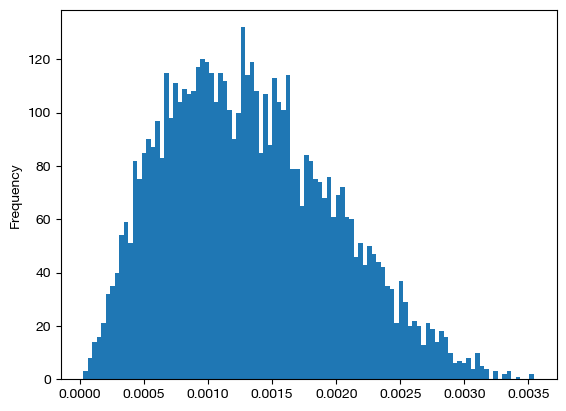

In [190]:
g['rand_10b'].plot(kind='hist', bins=100)

In [39]:
gg['Call Category'].value_counts()

Call Category
Patrol                       2978
Medical/Welfare               946
Motor Vehicle Enforcement     561
Investigation                 374
Emergency                     346
Complaint                     195
Alarms                        161
Motor Vehicle Accident        119
Name: count, dtype: int64

In [ ]:

gg.to_csv('/Users/joel/Desktop/Police_Activity.csv', index=False)